# **Chi2 comparison for stargal**

We are comparing two **non-nested models** of sed's photometry varying over less or more free parameters. To do so, we computed the likelihood value (Chi2) of N sources to both of these models, and use statistical tests --suitables to compare non-nested models-- to find which one is better.

- **$\chi^2$ comparison methods**:
    - 1. $\chi^2_{best fit}$ comparison. Compare directly the best likelihood value from each library ($\chi^2_{star}$, $\chi^2_{gal}$). 
    - 2. $\mathrm{BIC}$ comparison. Compute the Bayesian Information Criterion (BIC): $\mathrm{BIC}_{m}=\chi^2_{m}+k_m\ln(n_{data}) \Rightarrow \mathrm{\Delta BIC}_{m,j}=\Delta\chi^2_{m,j}+(k_m-k_j)\ln(n_{data})$. Where $\Delta\chi^2_{m,j}=\chi^2_{m}-\chi^2_{j}$, $k_{m,j}$ is the number of free parameters in models {$m,j$} and $n_{data}$ is the number of observations for the source, i.e. $n_{bands}$ in our case. If $\Delta \mathrm{BIC} < 0$, model m is preferred, else it is model j. This is better than doing a direct $\chi^2_{m,j}$ comparison since the two models are non-nested in our case. Note that $\Delta \mathrm{BIC}$ is an approximation of $C_\mathrm{Bayes}$ for high $S/N$. It only requires $\chi^2_{best fit}$ of each models. 

## **0. Initialisation**

### Packages

In [ ]:
### Libs ###
from imports import *

base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(base_dir)

# Custom libraries
from scripts import statsplot as ssp
from scripts import utils as sutils

%matplotlib inline

### Catalog(s)

test with dc2

In [2]:
# The output of zphota is mandatory for BIC method
# trilegal_BT_LSST_photoz = sutils.lephare_to_pandas(f"{base_dir}/catalogs/DC2/trilegal_dc2_errors_buzzard_BT_LSST_full.out")
# dc2_BT_LSST_photoz = sutils.lephare_to_pandas(f"{base_dir}/catalogs/DC2/dp02_dc2_62_BT_LSST_full.out")
# photoz_cat = pd.concat((dc2_BT_LSST_photoz, trilegal_BT_LSST_photoz))

dc2_BT_LSST_photoz = sutils.lephare_to_pandas(f"{base_dir}/catalogs/DC2/dp02_dc2_62_BT_LSST_full.out")
dc2_stars = dc2_BT_LSST_photoz[dc2_BT_LSST_photoz["ZSPEC"]==0]
dc2_gals = dc2_BT_LSST_photoz[dc2_BT_LSST_photoz["ZSPEC"]>1][:6579]
photoz_cat = pd.concat((dc2_stars, dc2_gals))

In [3]:
# Keep what is useful
photoz_cat= photoz_cat[['IDENT','CHI_BEST', 'CHI_STAR', 'NBAND_USED',
                            'MAG_OBS0', 'MAG_OBS1', 'MAG_OBS2', 'MAG_OBS3', 'MAG_OBS4', 'MAG_OBS5',
                            'ERR_MAG_OBS0', 'ERR_MAG_OBS1', 'ERR_MAG_OBS2', 'ERR_MAG_OBS3', 'ERR_MAG_OBS4', 'ERR_MAG_OBS5', 'ZSPEC']].copy()

# ZSPEC=0 -> star
photoz_cat["IS_STAR"] = (photoz_cat["ZSPEC"] == 0).astype(int)
# photoz_cat["IS_STAR"] = (photoz_cat["refExtendedness"] == 0).astype(int)
photoz_cat[photoz_cat["IS_STAR"]==1][:3]

,IDENT,CHI_BEST,CHI_STAR,NBAND_USED,MAG_OBS0,MAG_OBS1,MAG_OBS2,MAG_OBS3,MAG_OBS4,MAG_OBS5,ERR_MAG_OBS0,ERR_MAG_OBS1,ERR_MAG_OBS2,ERR_MAG_OBS3,ERR_MAG_OBS4,ERR_MAG_OBS5,ZSPEC,IS_STAR
0,1651413688361421449,2.52301,5.54265,6,26.112,26.669,25.962,25.452,25.985,24.877,0.445,0.249,0.155,0.191,0.823,0.523,0.0,1
1,1651413688361451863,5.76531,19.80850,6,28.114,25.847,25.458,24.611,24.224,24.009,2.443,0.108,0.091,0.082,0.145,0.210,0.0,1
193,1651413688361451488,537.11800,72.19620,6,22.446,21.390,21.021,20.882,20.846,20.826,0.012,0.002,0.001,0.002,0.005,0.010,0.0,1


### Parameters

In [4]:
#--- Parameters ---
kG = 3 # dof of model A. Unknow, Z, alpha (normalisation)
kS = 4 # dof of model B. Teff, logg, FeH, alpha (normalisation)
nbands = 6 # ugrizy

#--- Preferences ---
ignore_aberrant_Z = True # sometimes best-likelihood can't be compute during photo-z
                         # yet it returns Z = -99

## **1. $\chi^2_{best fit}$ Direct Comparison**

### Compute P(star)

In [5]:
def model_prob_from_chi(Chi_A, Chi_B, prior_A=0.5, prior_B=0.5):
    '''
    Compute the posterior from likelihood parameter.
    '''
    wA = prior_A * np.exp(-0.5 * Chi_A)
    wB = prior_B * np.exp(-0.5 * Chi_B)

    norm = wA + wB
    return wA / norm, wB / norm

In [6]:
# Main loop
if ignore_aberrant_Z == True:
    photoz_cat = photoz_cat[photoz_cat['CHI_BEST']<1e9]

#We consider "star" to be the positive class.
P_STAR = []

for source in photoz_cat.itertuples():
    chiG = source.CHI_BEST
    chiS = source.CHI_STAR
    p_Gx, p_Sx = model_prob_from_chi(chiG, chiS)#, prior_A=0.9,prior_B=0.1)
    P_STAR.append(p_Sx)

photoz_cat["P_STAR"] = P_STAR

/tmp/ipykernel_25975/734253073.py:9: RuntimeWarning: invalid value encountered in scalar divide
  return wA / norm, wB / norm


### Statistics

In [7]:
#--- Rates at P_STAR >= P_threshold ---
P_threshold = 0.95

tp = len(photoz_cat[(photoz_cat["P_STAR"]>P_threshold) & (photoz_cat["IS_STAR"]==1)]) #True Positives
tn = len(photoz_cat[(photoz_cat["P_STAR"]<P_threshold) & (photoz_cat["IS_STAR"]==0)]) #True Negatives
fp = len(photoz_cat[(photoz_cat["P_STAR"]>P_threshold) & (photoz_cat["IS_STAR"]==0)]) #False Positives
fn = len(photoz_cat[(photoz_cat["P_STAR"]<P_threshold) & (photoz_cat["IS_STAR"]==1)]) #False Negatives

#Precision: fraction of relevant instances among the retrieved instances
precision = tp/(tp+fp)
recall = tp/(tp+fn) #tpr
fpr = fp/(fp+tn)
accuracy = (tp+tn)/(tp+tn+fp+fn)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("False Positive Rate:", round(fpr, 4))
print("Accuracy:", round(accuracy, 4))

Precision: 0.9572
Recall: 0.5815
False Positive Rate: 0.0219
Accuracy: 0.7969


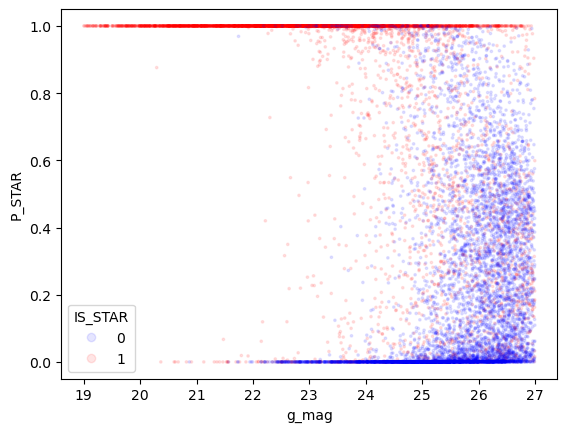

In [8]:
df_plot = photoz_cat[(photoz_cat["MAG_OBS1"]>19) & (photoz_cat["MAG_OBS1"]<27) & (photoz_cat["ERR_MAG_OBS1"]<1)].dropna() # 
# df_plot = df_plot[(df_plot["P_STAR"]<0.4) | (df_plot["P_STAR"]>0.65)]

plt.figure()
sc = plt.scatter(df_plot["MAG_OBS1"], df_plot["P_STAR"], c=df_plot["IS_STAR"], s=3, alpha=0.1, cmap="bwr")
plt.xlabel("g_mag")
plt.ylabel("P_STAR")
handles, labels = sc.legend_elements()
plt.legend(handles, labels, title="IS_STAR")
plt.show()

# plt.figure()
# plt.hist2d(df_plot["MAG_OBS1"], df_plot["P_STAR"], bins=(100,100), cmap='gist_stern')
# plt.colorbar(label="counts")
# plt.show()

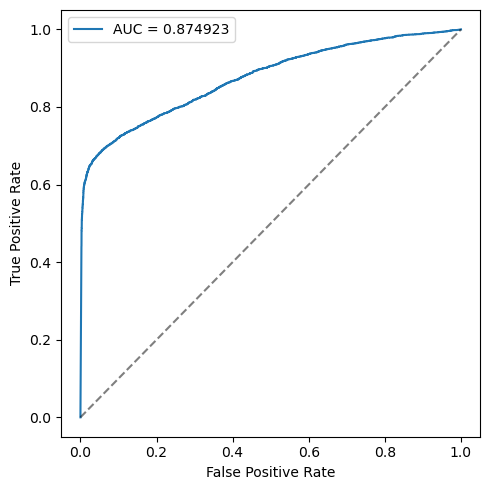

In [9]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

fpr, tpr, thresholds = roc_curve(df_plot["IS_STAR"], df_plot["P_STAR"], pos_label=1)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.6f}")
plt.plot([0,1], [0,1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


## **2. BIC Comparison**

### Compute P(star) BIC

In [10]:
def BIC(chi2, k, n):
    '''
    Compute BIC from chi2, k (dof) and n (n_bands).
    '''
    return chi2 + k*np.log(n)

# model_prob_from_chi stay the same, we just have to replace chi2 by BIC.

In [11]:
P_STAR_BIC = []

# Same loop but with BIC
for source in photoz_cat.itertuples():
    chiG = source.CHI_BEST
    chiS = source.CHI_STAR
    BIC_G = BIC(chiG, kG, source.NBAND_USED)
    BIC_S = BIC(chiS, kS, source.NBAND_USED)
    pBIC_Gx, pBIC_Sx = model_prob_from_chi(BIC_G, BIC_S)#, prior_A=0.9,prior_B=0.1)
    P_STAR_BIC.append(pBIC_Sx)

photoz_cat["P_STAR_BIC"] = P_STAR_BIC

/tmp/ipykernel_25975/734253073.py:9: RuntimeWarning: invalid value encountered in scalar divide
  return wA / norm, wB / norm


### Statistics

In [12]:
#--- Rates at P_STAR_BIC >= P_threshold ---
P_threshold = 0.95

tp = len(photoz_cat[(photoz_cat["P_STAR_BIC"]>P_threshold) & (photoz_cat["IS_STAR"]==1)]) #True Positives
tn = len(photoz_cat[(photoz_cat["P_STAR_BIC"]<P_threshold) & (photoz_cat["IS_STAR"]==0)]) #True Negatives
fp = len(photoz_cat[(photoz_cat["P_STAR_BIC"]>P_threshold) & (photoz_cat["IS_STAR"]==0)]) #False Positives
fn = len(photoz_cat[(photoz_cat["P_STAR_BIC"]<P_threshold) & (photoz_cat["IS_STAR"]==1)]) #False Negatives

#Precision: fraction of relevant instances among the retrieved instances
precision = tp/(tp+fp)
recall = tp/(tp+fn)
fpr = fp/(fp+tn)
accuracy = (tp+tn)/(tp+tn+fp+fn)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("False Positive Rate:", round(fpr, 4))
print("Accuracy:", round(accuracy, 4))

Precision: 0.9688
Recall: 0.5617
False Positive Rate: 0.0152
Accuracy: 0.7916


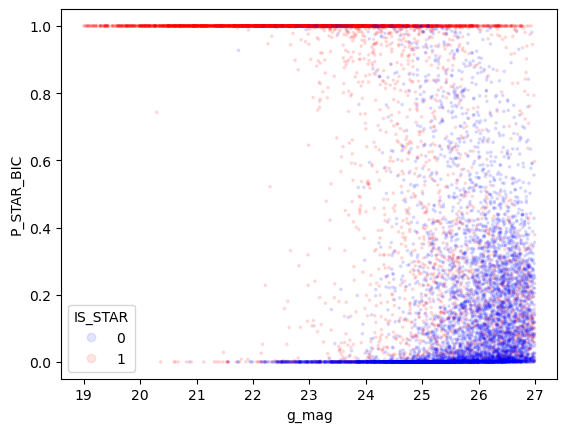

In [13]:
df_plot = photoz_cat[(photoz_cat["MAG_OBS1"]>19) & (photoz_cat["MAG_OBS1"]<27) & (photoz_cat["ERR_MAG_OBS1"]<1)].dropna() # 
# df_plot = df_plot[(df_plot["P_STAR"]<0.4) | (df_plot["P_STAR"]>0.65)]

plt.figure()
sc = plt.scatter(df_plot["MAG_OBS1"], df_plot["P_STAR_BIC"], c=df_plot["IS_STAR"], s=3, alpha=0.1, cmap="bwr")
plt.xlabel("g_mag")
plt.ylabel("P_STAR_BIC")

handles, labels = sc.legend_elements()
plt.legend(handles, labels, title="IS_STAR")
plt.show()

# plt.figure()
# plt.hist2d(df_plot["MAG_OBS1"], df_plot["P_STAR_BIC"], bins=(100,100), cmap='gist_stern')
# plt.colorbar(label="counts")
# plt.show()

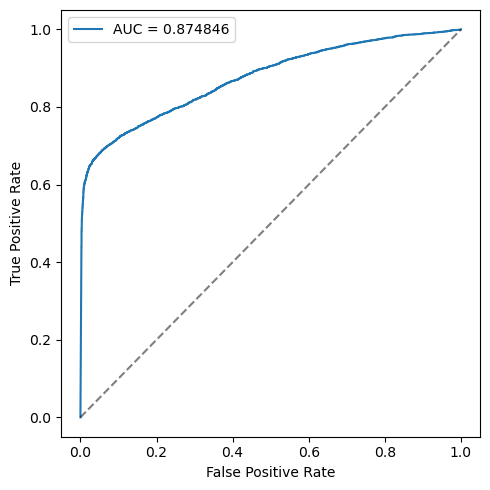

In [14]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

fpr, tpr, thresholds = roc_curve(df_plot["IS_STAR"], df_plot["P_STAR_BIC"], pos_label=1)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.6f}")
plt.plot([0,1], [0,1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


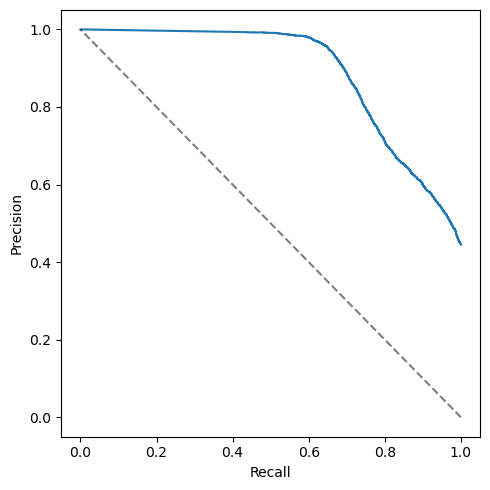

In [15]:
y_true = df_plot["IS_STAR"].values
y_score = df_plot["P_STAR_BIC"].values

precision, recall, thresholds = precision_recall_curve(y_true, y_score)

plt.figure(figsize=(5,5))
plt.plot(recall, precision)
plt.plot([1,0], [0,1], "k--", alpha=0.5)
plt.xlabel("Recall")
plt.ylabel("Precision")
# plt.legend()
plt.tight_layout()
plt.show()

### Target purity

In [16]:
target_purity = 0.95
valid = precision[:-1] >= target_purity

if not np.any(valid):
    print("No threshold reaches 95% purity")
else:
    idx = np.where(valid)[0]
idx

if not np.any(valid):
    raise RuntimeError("No threshold reaches 95% precision")

# among valid thresholds, choose the one with MAX recall
best_idx = np.argmax(recall[:-1][valid])
threshold_idx = np.where(valid)[0][best_idx]
pstar_threshold = thresholds[threshold_idx]

print(f"Pstar threshold for {target_purity} purity:", round(pstar_threshold, 4))

Pstar threshold for 0.95 purity: 0.8539
